# This notebook is to outline the steps I take to calculate cloud optical depth from the extinction coefficients in EarthCARE's CAP product

In [1]:
# import packages
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm

import datetime
from datetime import datetime, timedelta

import h5py
import numpy as np

from scipy.integrate import cumulative_trapezoid

# function for masking bad values
def mask_ext(data):

    """
    input:
    data: an array of extinction coefficients from CAP (or any variable with the same missing/fill values)

    output:
    ext_masked: the same array, but with fill/missing values masked out
    
    """
    
    ext_maske = np.where(data < 9.96921e+36, data, np.nan) # mask missing values
    ext_masked = np.where(ext_maske >= 0, ext_maske, np.nan) # mask negative values

    return ext_masked

# Step 1: Obtain the EarthCARE CAP file you are interested in looking at, and read in the extinction variables

In [2]:
cap_file_use = '/mnt/sat/earthcare/ACM_CAP_2B/BA/2025/06/01/ECA_EXBA_ACM_CAP_2B_20250601T075503Z_20250930T034233Z_05732A.h5'

In [3]:
# read in the 3 extinction variables: liquid, ice, and aerosol

f_cap_earthcare = h5py.File(cap_file_use, 'r')

ext_vars = ['liquid_extinction','ice_extinction','aerosol_extinction']

# read in the variables while also masking fill/missing values
cap_liq = mask_ext(f_cap_earthcare['ScienceData'][ext_vars[0]][:]) # [m-1]
cap_ice = mask_ext(f_cap_earthcare['ScienceData'][ext_vars[1]][:]) # [m-1]
cap_aer = mask_ext(f_cap_earthcare['ScienceData'][ext_vars[2]][:]) # [m-1]

# combine these 3 ext variables into one full atmospheric extinction variable
totalex = np.nansum(np.dstack((cap_liq,cap_ice,cap_aer)), 2)

# read in height variable as well (necessary for integration later)
cap_hght = f_cap_earthcare['ScienceData']['height'][:] # [m]

# read in latitude and create a 2D lat_grid (necessary for plotting later)
cap_lat = f_cap_earthcare['ScienceData']['latitude'][:]

cap_lat_grid, _ = np.meshgrid(cap_lat, 
                          np.arange(cap_hght.shape[1]), 
                          indexing='ij')


# Step 2: Calculate optical depth using the relationship:
# $$ \tau = -\int_{\mathrm{TOA}}^{\mathrm{SFC}} \beta_{\mathrm{ext}} \, dz $$
# where $ \tau $ is optical depth and $ \beta_{\mathrm{ext}} $ is totalex calculated in the previous cell

In [12]:
# using the relationship outlined above and using scipy's cumulative trapezoid function,
# we can now calculate optical depth for this case

# totalex is in units of m-1 and cap_hght is in units of m

# must multiply by negative 1, since integrating from TOA to SFC results in negative values 
# due to decreasing heights

opd = cumulative_trapezoid(totalex, x = cap_hght, axis=1, initial=0) * -1

# Step 3: Plot the results to make sure they look correct

/tmp/ipykernel_1215483/73624490.py:9: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax1.pcolormesh(cap_lat_grid, cap_hght / 1000, totalex, cmap='inferno',
/tmp/ipykernel_1215483/73624490.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax2.pcolormesh(cap_lat_grid, cap_hght / 1000, opd, cmap='inferno',


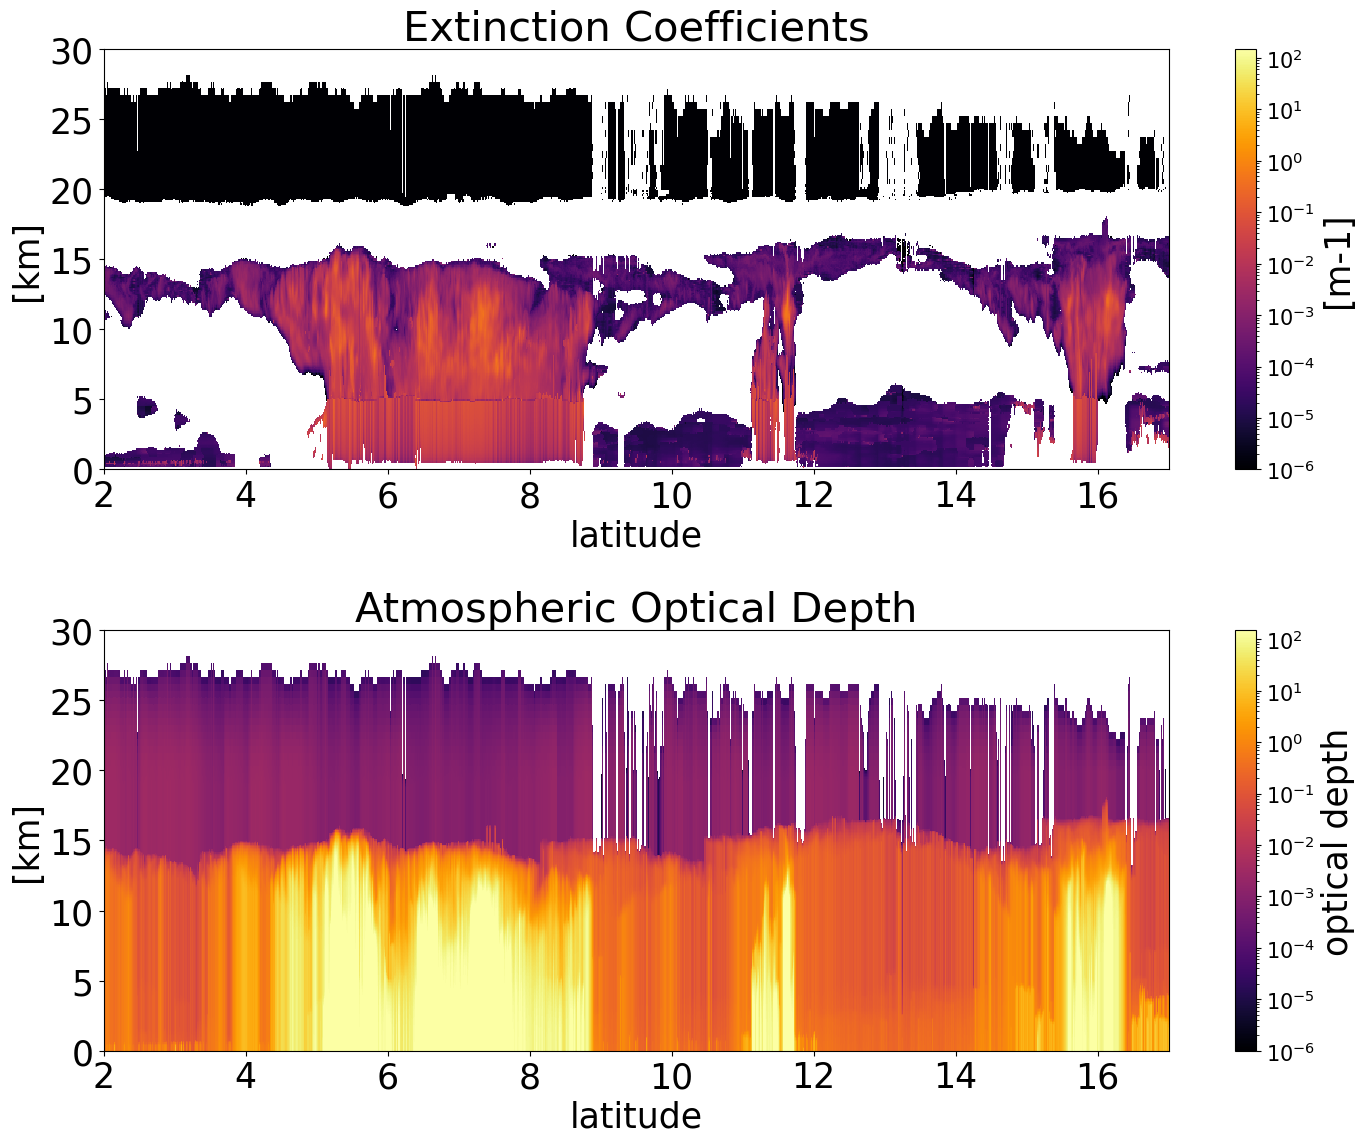

In [13]:
fig = plt.figure(figsize=(15,12))

plt.rcParams.update({'font.size': 25})

ax1 = plt.subplot(2,1,1)
ax2 = plt.subplot(2,1,2,sharex=ax1,sharey=ax1)

# plotting ext coefficients
pcm = ax1.pcolormesh(cap_lat_grid, cap_hght / 1000, totalex, cmap='inferno', 
                     norm=mcolors.LogNorm(vmin=1e-6,vmax=150))

cbar = plt.colorbar(ax=ax1, mappable = pcm,orientation='vertical',
                    label='[m-1]')
cbar.ax.tick_params(labelsize=15) 

ax1.set_xlabel('latitude')
ax1.set_ylabel('[km]')
ax1.set_ylim(0,30)
ax1.set_xlim(2,17)

ax1.set_title('Extinction Coefficients')

# plotting optical depth
pcm = ax2.pcolormesh(cap_lat_grid, cap_hght / 1000, opd, cmap='inferno', 
                     norm=mcolors.LogNorm(vmin=1e-6,vmax=150))

cbar = plt.colorbar(ax=ax2, mappable = pcm,orientation='vertical',
                    label='optical depth')
cbar.ax.tick_params(labelsize=15) 

ax2.set_xlabel('latitude')
ax2.set_ylabel('[km]')

ax2.set_title('Atmospheric Optical Depth')

plt.tight_layout()

plt.show()